# Experiment 4: Transfer Learning Using Pre-Trained Vision Models for Image Recognition


---





In [17]:
print("   EXPERIMENT 4: TRANSFER LEARNING")
print("Name    : SWATHI V")
print("Roll No : 24BAD122")


   EXPERIMENT 4: TRANSFER LEARNING
Name    : SWATHI V
Roll No : 24BAD122


In [1]:
# Install required libraries (Colab already has most, this ensures correct versions)
!pip install -q kagglehub tensorflow matplotlib scikit-learn transformers torch torchvision pillow
print("All packages installed successfully.")


All packages installed successfully.


In [2]:
# Imports
import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## TASK A: Dataset Preparation

**Sub-tasks:**
1. Download an image dataset from Kaggle.
2. Load and preprocess the images.
3. Split the dataset into training, validation, and testing sets.

We use the **Flowers Recognition** dataset from Kaggle (5 classes: daisy, dandelion, rose, sunflower, tulip — a good size for a quick transfer-learning demo).

### Step A.1 — Authenticate & Download from Kaggle

**Input:** Your Kaggle API credentials (`kaggle.json`)
**Output:** Local path containing the downloaded dataset

> To get `kaggle.json`: go to https://www.kaggle.com/settings -> "Create New Token" -> it downloads `kaggle.json`. Upload it below when prompted.


In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "alxmamaev/flowers-recognition"
)

print(dataset_path)

In [5]:
import kagglehub

# Download the Flowers Recognition dataset from Kaggle
# Dataset: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
dataset_path = kagglehub.dataset_download("alxmamaev/flowers-recognition")
print("Input : Kaggle dataset id -> 'alxmamaev/flowers-recognition'")
print("Output: Dataset downloaded to ->", dataset_path)

# Inspect folder structure
for root, dirs, files_ in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    print('  ' * level + os.path.basename(root) + '/')
    if level > 1:
        continue


100%|██████████| 225M/225M [00:11<00:00, 20.7MB/s]

Extracting files...


Input : Kaggle dataset id -> 'alxmamaev/flowers-recognition'
Output: Dataset downloaded to -> /root/.cache/kagglehub/datasets/alxmamaev/flowers-recognition/versions/2
2/
  flowers/
    sunflower/
    daisy/
    tulip/
    rose/
    dandelion/


In [6]:
# Locate the actual image root (contains one sub-folder per class)
DATA_DIR = None
for root, dirs, files_ in os.walk(dataset_path):
    if len(dirs) >= 5 and all(not d.startswith('.') for d in dirs):
        DATA_DIR = root
        break

print("Output: Image root directory containing class folders ->", DATA_DIR)
print("Classes found:", os.listdir(DATA_DIR))


Output: Image root directory containing class folders -> /root/.cache/kagglehub/datasets/alxmamaev/flowers-recognition/versions/2/flowers
Classes found: ['sunflower', 'daisy', 'tulip', 'rose', 'dandelion']


### Step A.2 — Load, Preprocess, and Split the Dataset

**Input:** Raw images in `DATA_DIR/<class_name>/*.jpg`
**Output:** `train_ds`, `val_ds`, `test_ds` — batched, resized (224x224 for ResNet-50), normalized `tf.data.Dataset` objects


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# 80% train, 20% temp -> split temp into 10% val / 10% test
full_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

class_names = full_ds.class_names
num_classes = len(class_names)
print("Output: Detected classes ->", class_names)

n_batches = tf.data.experimental.cardinality(full_ds).numpy()
train_size = int(0.8 * n_batches)
val_size = int(0.1 * n_batches)

train_ds = full_ds.take(train_size)
remaining = full_ds.skip(train_size)
val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)

print(f"Output: Train batches={tf.data.experimental.cardinality(train_ds).numpy()}, "
      f"Val batches={tf.data.experimental.cardinality(val_ds).numpy()}, "
      f"Test batches={tf.data.experimental.cardinality(test_ds).numpy()}")


Found 4317 files belonging to 5 classes.
Output: Detected classes -> ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Output: Train batches=108, Val batches=13, Test batches=14


In [8]:
# Preprocess (ResNet50-specific normalization) and prefetch for performance
def preprocess(image, label):
    image = preprocess_input(image)
    return image, label

train_ds = train_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)

print("Output: Datasets preprocessed and ready for training.")


Output: Datasets preprocessed and ready for training.


Found 4317 files belonging to 5 classes.


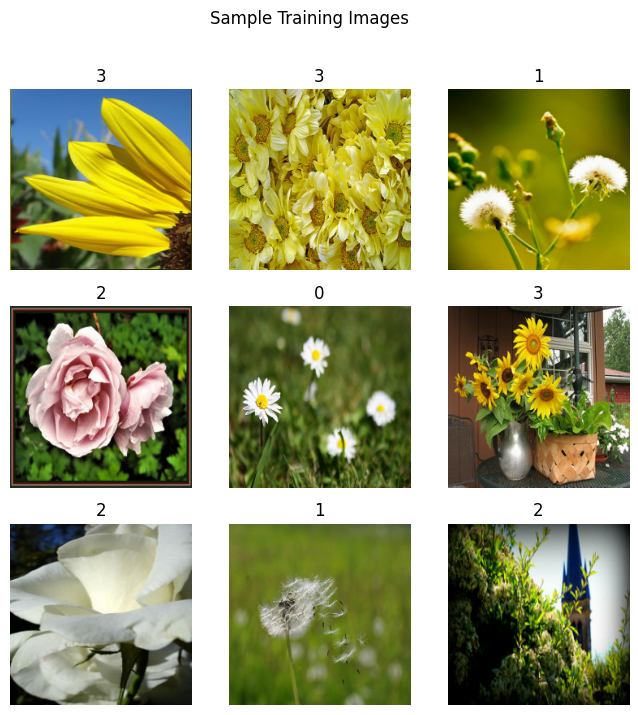

In [9]:
# Visualize a sample batch (Input: raw images from dataset, Output: displayed grid with labels)
sample_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, image_size=IMG_SIZE, batch_size=9, shuffle=True, seed=SEED
)
plt.figure(figsize=(8, 8))
for images, labels in sample_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.argmax(tf.one_hot(labels[i], num_classes)) if False else int(labels[i])] if False else str(int(labels[i])))
        plt.axis("off")
plt.suptitle("Sample Training Images")
plt.show()


---
## TASK B: Implementing Transfer Learning

**Sub-tasks:**
1. Load a pre-trained model (ResNet-50).
2. Replace the final classification layer according to the dataset classes.
3. Freeze the feature extraction layers.
4. Compile the model.

**Input:** ImageNet-pretrained ResNet-50 (`weights='imagenet'`, `include_top=False`)
**Output:** A compiled Keras model ready for training, with a new classification head for our 5 flower classes


In [10]:
# Load pre-trained ResNet-50 without its original classification head
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all feature-extraction layers (they keep their ImageNet-learned weights)
base_model.trainable = False
print(f"Output: Loaded ResNet-50 with {len(base_model.layers)} layers, all frozen.")

# Build the new classifier head on top
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Output: Loaded ResNet-50 with 175 layers, all frozen.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

---
## TASK C: Model Training and Performance Evaluation

**Sub-tasks:**
1. Train the transfer learning model.
2. Record training/validation accuracy & loss and test accuracy.
3. Visualize Accuracy vs Epoch and Loss vs Epoch.

**Input:** `train_ds`, `val_ds` prepared in Task A
**Output:** Trained model + `history` object with per-epoch metrics


In [11]:
EPOCHS = 10

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop]
)


Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 38s 216ms/step - accuracy: 0.6354 - loss: 0.9884 - val_accuracy: 0.8317 - val_loss: 0.5062
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 27s 157ms/step - accuracy: 0.8302 - loss: 0.4805 - val_accuracy: 0.8654 - val_loss: 0.3713
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 24s 194ms/step - accuracy: 0.8756 - loss: 0.3682 - val_accuracy: 0.8846 - val_loss: 0.3553
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 18s 169ms/step - accuracy: 0.9005 - loss: 0.3042 - val_accuracy: 0.9038 - val_loss: 0.2845
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 159ms/step - accuracy: 0.9068 - loss: 0.2703 - val_accuracy: 0.9159 - val_loss: 0.2644
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 160ms/step - accuracy: 0.9178 - loss: 0.2377 - val_accuracy: 0.9255 - val_loss: 0.2371
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 19s 174ms/step - accuracy: 0.9242 - loss: 0.2134 - val_accuracy: 0.9159 - val_loss: 0.2494
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 158ms/step - accuracy: 0.9366 - loss: 0

In [12]:
# Output: Final recorded metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss   = history.history['val_loss'][-1]

print(f"Training accuracy   : {final_train_acc:.4f}")
print(f"Validation accuracy : {final_val_acc:.4f}")
print(f"Training loss        : {final_train_loss:.4f}")
print(f"Validation loss       : {final_val_loss:.4f}")


Training accuracy   : 0.9517
Validation accuracy : 0.9351
Training loss        : 0.1529
Validation loss       : 0.2037


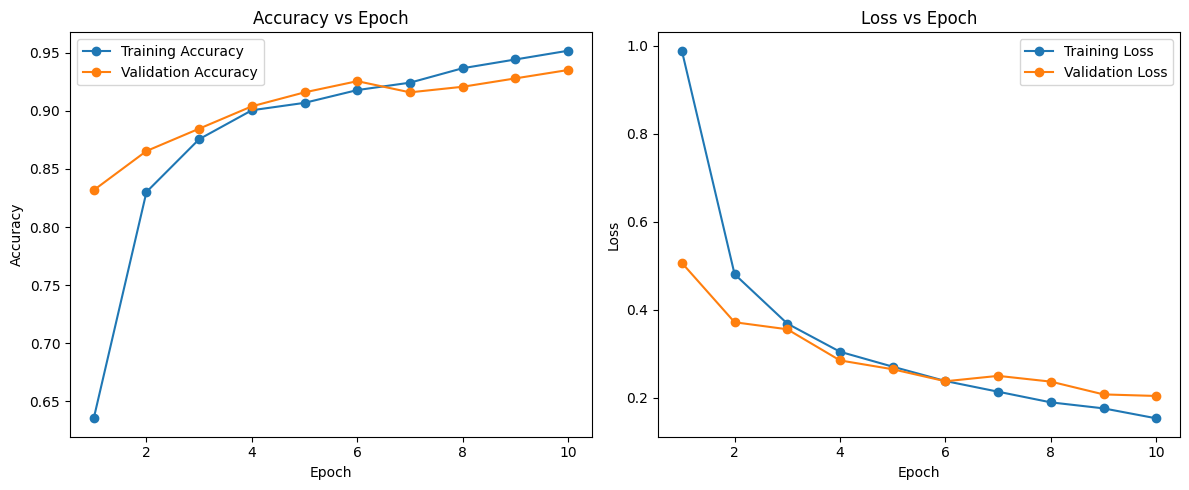

In [13]:
# Visualize: Accuracy vs Epoch and Loss vs Epoch
# Input: history object   Output: two plots
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [18]:
# Evaluate on the held-out test set
# Input: test_ds   Output: test loss & test accuracy
test_loss, test_acc = model.evaluate(test_ds)
print(f"Output -> Test Loss: {test_loss:.4f}   Test Accuracy: {test_acc:.4f}")


14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 491ms/step - accuracy: 0.9169 - loss: 0.2325
Output -> Test Loss: 0.2325   Test Accuracy: 0.9169


---
## TASK D: Using Hugging Face Pre-Trained Models

**Sub-tasks:**
1. Load a pre-trained vision model from Hugging Face.
2. Perform image classification on sample images.
3. Compare predictions with the transfer learning model.
4. Document observations.

**Input:** A few sample images from the test set + Hugging Face `google/vit-base-patch16-224` model
**Output:** Predicted class labels from both the Hugging Face model and our fine-tuned ResNet-50, shown side by side


In [14]:
from transformers import pipeline
from PIL import Image

# Load a pre-trained Vision Transformer (ViT) from Hugging Face for image classification
hf_classifier = pipeline("image-classification", model="google/vit-base-patch16-224")
print("Output: Hugging Face ViT pipeline loaded successfully.")


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Output: Hugging Face ViT pipeline loaded successfully.


In [15]:
import glob

# Grab a handful of sample images directly from disk (Input: raw image files)
sample_files = []
for cls in class_names:
    files_in_cls = glob.glob(os.path.join(DATA_DIR, cls, "*"))
    if files_in_cls:
        sample_files.append(random.choice(files_in_cls))

print("Output: Selected sample images ->")
for f in sample_files:
    print(" ", f)


Output: Selected sample images ->
  /root/.cache/kagglehub/datasets/alxmamaev/flowers-recognition/versions/2/flowers/daisy/9180706736_092d43088c.jpg
  /root/.cache/kagglehub/datasets/alxmamaev/flowers-recognition/versions/2/flowers/dandelion/34717754295_cbb0185a36_n.jpg
  /root/.cache/kagglehub/datasets/alxmamaev/flowers-recognition/versions/2/flowers/rose/15949087094_a8f565295c_m.jpg
  /root/.cache/kagglehub/datasets/alxmamaev/flowers-recognition/versions/2/flowers/sunflower/15839183375_49bf4f75e8_m.jpg
  /root/.cache/kagglehub/datasets/alxmamaev/flowers-recognition/versions/2/flowers/tulip/16568550940_d64ee7898f_n.jpg


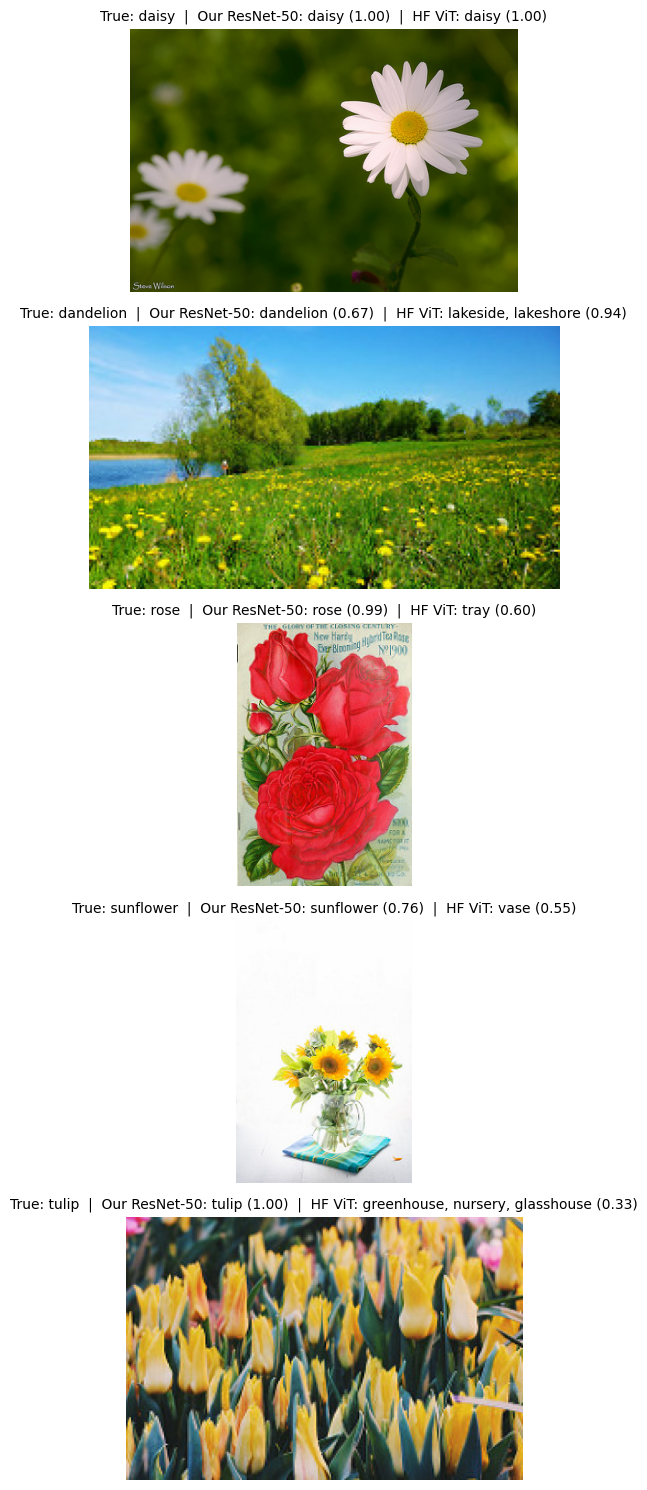

In [16]:
# Run predictions from BOTH models on the same sample images and compare
plt.figure(figsize=(15, 3 * len(sample_files)))

for i, img_path in enumerate(sample_files):
    pil_img = Image.open(img_path).convert("RGB")

    # --- Hugging Face ViT prediction ---
    hf_pred = hf_classifier(pil_img)[0]  # top-1 result: {'label':..., 'score':...}

    # --- Our fine-tuned ResNet-50 prediction ---
    img_resized = pil_img.resize((224, 224))
    arr = np.expand_dims(np.array(img_resized), axis=0).astype('float32')
    arr = preprocess_input(arr)
    our_pred_probs = model.predict(arr, verbose=0)[0]
    our_pred_label = class_names[np.argmax(our_pred_probs)]
    our_pred_conf = np.max(our_pred_probs)

    true_label = os.path.basename(os.path.dirname(img_path))

    ax = plt.subplot(len(sample_files), 1, i + 1)
    plt.imshow(pil_img)
    plt.axis('off')
    plt.title(
        f"True: {true_label}  |  Our ResNet-50: {our_pred_label} ({our_pred_conf:.2f})  |  "
        f"HF ViT: {hf_pred['label']} ({hf_pred['score']:.2f})",
        fontsize=10
    )

plt.tight_layout()
plt.show()


### Observations (sample discussion — update with your actual results)

- The Hugging Face ViT model was trained on the full **ImageNet-1k** label set (1000 general classes), so its labels may not exactly match our flower class names, but it usually identifies the correct general category (e.g., "daisy", "pot", "vase") because flowers/plants exist in ImageNet.
- Our fine-tuned ResNet-50 was trained specifically on the 5 flower classes, so it gives **more precise and directly usable labels** for this task, at the cost of only working within those 5 classes.
- The Hugging Face model required **zero training** and gave instant predictions, demonstrating the practical value of using pre-trained, task-agnostic vision models for quick inference.
- Overall, transfer learning (fine-tuned ResNet-50) is better when you need **high accuracy on a specific, narrow set of classes**, while a general-purpose Hugging Face model is better for **quick, general-purpose classification without any training**.


### Uploading the Notebook to GitHub

1. In Colab: **File -> Save a copy in GitHub**.
2. Choose (or create) your repository, e.g. `transfer-learning-lab`.
3. Add a commit message (e.g., "Add Experiment 4: Transfer Learning notebook").
4. Click **OK** — Colab will push the `.ipynb` file to your repository.
5. Copy the resulting GitHub URL and include it in your submission.
